2026-01-05 17:22:50,803 - src.graph.workflow - INFO - ======================================================================
2026-01-05 17:22:50,804 - src.graph.workflow - INFO - Building LangGraph Workflow
2026-01-05 17:22:50,804 - src.graph.workflow - INFO - ======================================================================
2026-01-05 17:22:50,805 - src.graph.workflow - INFO - Model: llama3.2
2026-01-05 17:22:50,805 - src.graph.workflow - INFO - Checkpointer: Enabled
2026-01-05 17:22:50,805 - src.graph.workflow - INFO - Initializing StateGraph with TextAnalysisState schema
2026-01-05 17:22:50,805 - src.graph.workflow - INFO - Adding nodes:
2026-01-05 17:22:50,805 - src.graph.workflow - INFO -   - input_processor: Calculates word count from input text
2026-01-05 17:22:50,805 - src.graph.workflow - INFO -   - dummy_middle_node: Reads state and prints without returning
2026-01-05 17:22:50,807 - src.graph.workflow - INFO -   - summarizer: Generates summary and sentiment using llama3.

digraph {
	__start__
	input_processor
	dummy_middle_node
	summarizer
	__end__
	__start__ -> input_processor
	dummy_middle_node -> summarizer
	input_processor -> dummy_middle_node
	summarizer -> __end__
}



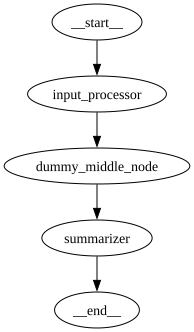

In [2]:
import sys
from pathlib import Path

# Add backend directory to path to maintain package structure
backend_path = Path.cwd()
sys.path.insert(0, str(backend_path))

from IPython.display import Image, display, SVG
import graphviz
from src.graph.workflow import create_workflow

# Create graph instance
app = create_workflow()

# Convert to graphviz
dot = graphviz.Digraph()
for node in app.get_graph().nodes:
    dot.node(str(node))

for edge in app.get_graph().edges:
    if not (edge[0] == "query_gen" and edge[1] == "__end__"):
        if edge == ("query_gen", "format_answer"):
            dot.edge(
                str(edge[0]), str(edge[1]),
                label="max_iter",
                fontcolor="red",
                fontsize="20",
                style="bold",
                decorate="true",
                tooltip="This edge is used when max_iter is reached"
            )
        else:
            dot.edge(str(edge[0]), str(edge[1]))

# Print DOT source for debugging
print(dot.source)

# Display the graph (try SVG for best label rendering)
# display(Image(dot.pipe(format='png')))
# Or, for SVG (uncomment the next line if you want SVG output)
display(SVG(dot.pipe(format='svg')))